# Supplementary Figure S4: Extended Cell-Type Analysis
Comprehensive cell-type/annotation-level Cauchy combination results across organs and replicates.

In [1]:
%matplotlib inline
import omicverse as ov
ov.style(font_path='Arial')

🔬 Starting plot initialization...
Using already downloaded Arial font from: /tmp/omicverse_arial.ttf
Registered as: Arial
🧬 Detecting GPU devices…
🚫 No GPU devices found (CUDA/MPS/ROCm/XPU)

   ____            _     _    __                  
  / __ \____ ___  (_)___| |  / /__  _____________ 
 / / / / __ `__ \/ / ___/ | / / _ \/ ___/ ___/ _ \ 
/ /_/ / / / / / / / /__ | |/ /  __/ /  (__  )  __/ 
\____/_/ /_/ /_/_/\___/ |___/\___/_/  /____/\___/                                              

🔖 Version: 2.1.1   📚 Tutorials: https://omicverse.readthedocs.io/
✅ plot_set complete.



In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import anndata as ad
import os
from scipy.stats import pearsonr

LEGEND_FS = 11; TICK_FS = 12; LABEL_FS = 13; TITLE_FS = 13; TEXT_FS = 12

def save_all_formats(fig, basepath, dpi=300):
    fig.savefig(f"{basepath}.pdf", bbox_inches="tight", dpi=dpi)
    fig.savefig(f"{basepath}.png", bbox_inches="tight", dpi=dpi)
    fig.savefig(f"{basepath}.svg", bbox_inches="tight")

BASE = '../analysis/26_gsmap'
os.makedirs(f'{BASE}/figures', exist_ok=True)

## Load Cauchy combination results from all available samples

In [3]:
available_samples = sorted([d for d in os.listdir(f'{BASE}/models/gsmap_output/')
                            if os.path.isdir(f'{BASE}/models/gsmap_output/{d}')])

cauchy_dfs = []
for sname in available_samples:
    fpath = f'{BASE}/models/gsmap_output/{sname}/cauchy_combination/{sname}_AD.Cauchy.csv.gz'
    if os.path.exists(fpath):
        df = pd.read_csv(fpath)
        df['sample_name'] = sname
        organ = sname.rsplit('_', 1)[0].replace('_', ' ')
        replicate = 'CTRL1' if 'CTRL1' in sname else 'CTRL2'
        df['organ'] = organ
        df['replicate'] = replicate
        cauchy_dfs.append(df)

cauchy_all = pd.concat(cauchy_dfs, ignore_index=True)
cauchy_all['logp_cauchy'] = -np.log10(cauchy_all['p_cauchy'].clip(lower=1e-300))
print(f'Total annotation-level results: {len(cauchy_all)}')
print(cauchy_all.head())

Total annotation-level results: 86
                        annotation  p_cauchy  p_median        sample_name  \
0               Bone Marrow Tissue  0.000048  0.004568  Bone_Marrow_CTRL1   
1               Bone Marrow Tissue  0.000012  0.002441  Bone_Marrow_CTRL2   
2                            Other  0.000764  0.007918  Bone_Marrow_CTRL2   
3                     Fiber Tracts  0.004575  0.043001        Brain_CTRL1   
4  Cerebellar Cortex (Gran. Layer)  0.007884  0.031401        Brain_CTRL1   

         organ replicate  logp_cauchy  
0  Bone Marrow     CTRL1     4.322741  
1  Bone Marrow     CTRL2     4.931926  
2  Bone Marrow     CTRL2     3.117108  
3        Brain     CTRL1     2.339646  
4        Brain     CTRL1     2.103261  


## Panel A: Heatmap of annotation Cauchy p-values across samples

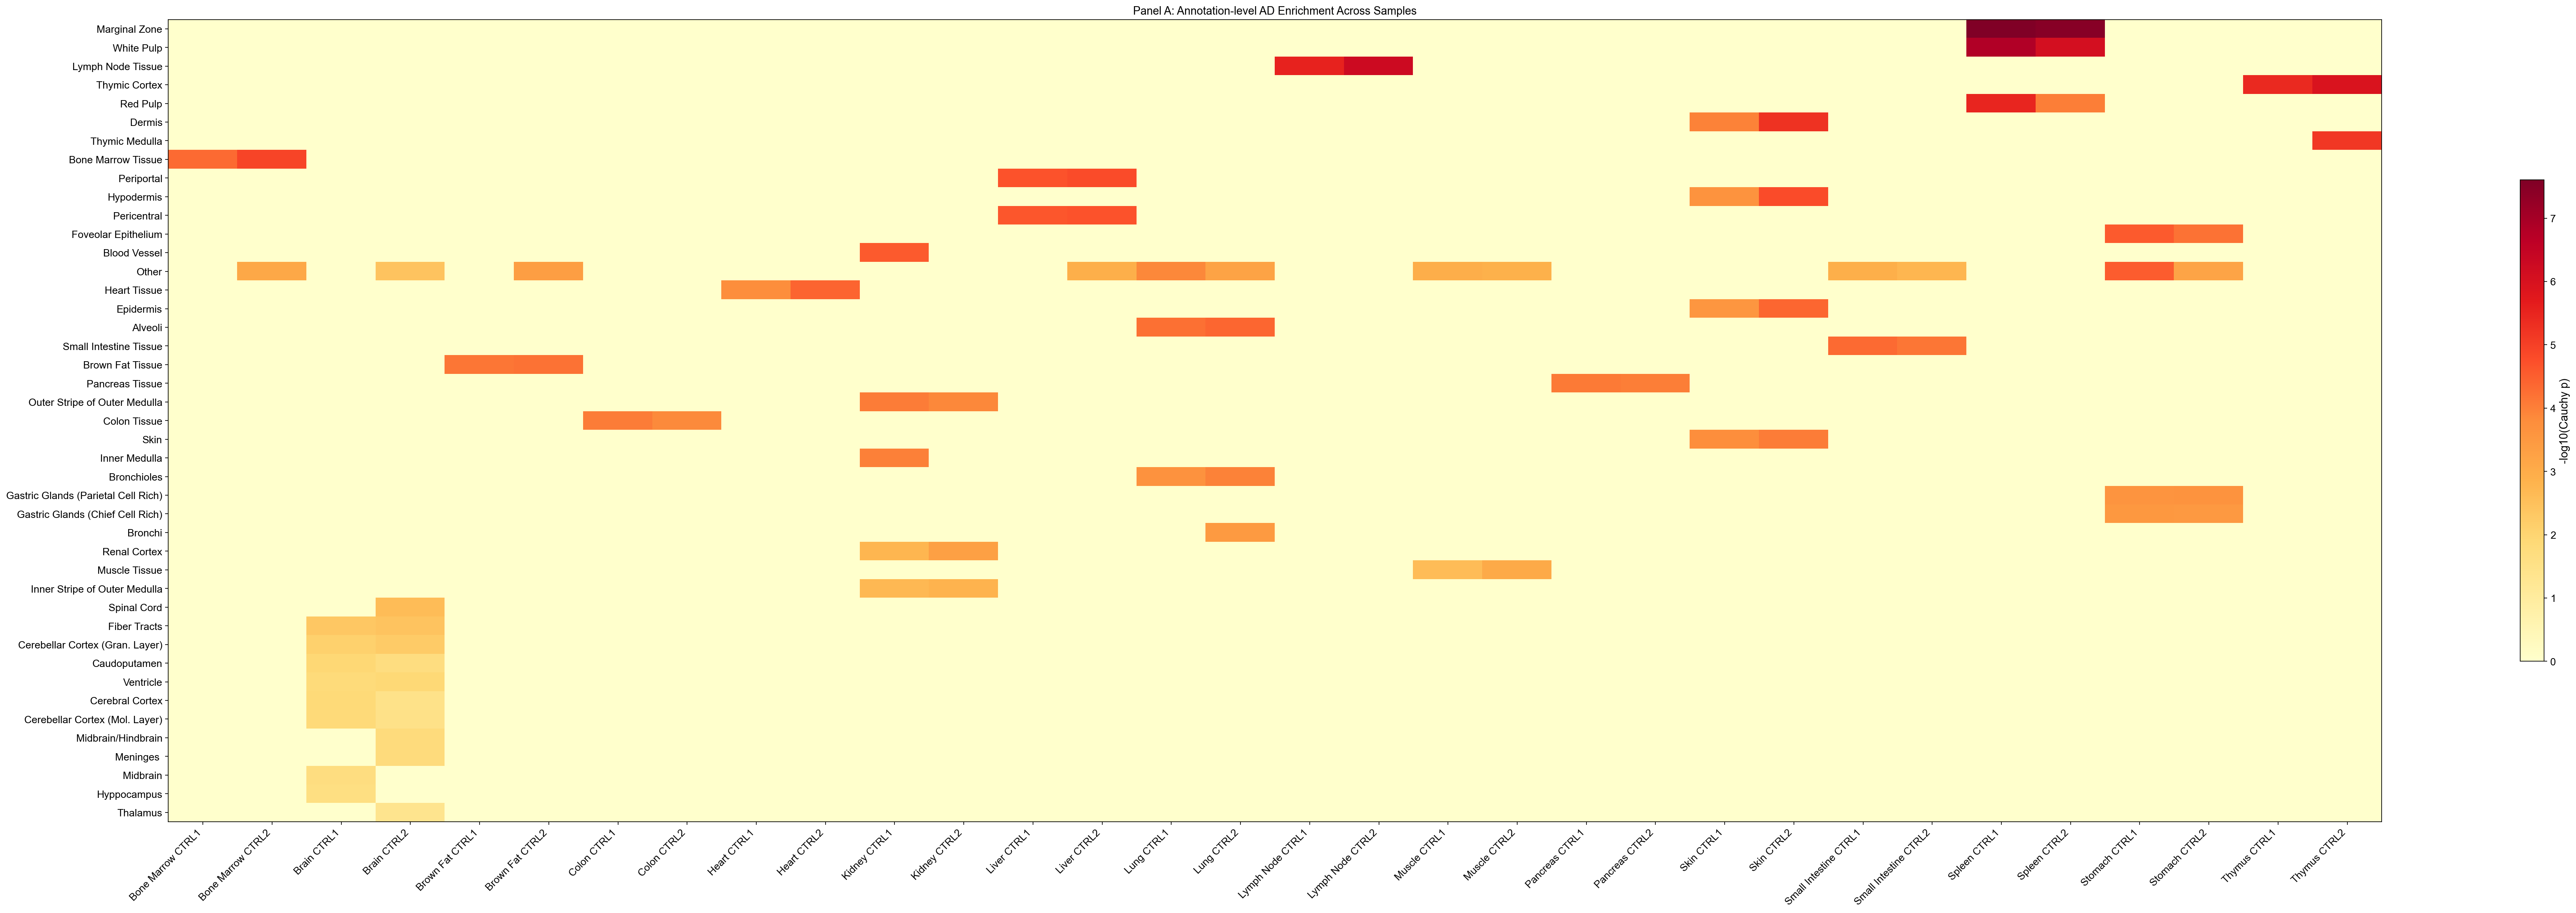

In [4]:
# Pivot to heatmap format: annotations x samples
pivot = cauchy_all.pivot_table(index='annotation', columns='sample_name', values='logp_cauchy', aggfunc='first')
pivot = pivot.fillna(0)

# Sort by max significance
pivot = pivot.loc[pivot.max(axis=1).sort_values(ascending=False).index]

fig, ax = plt.subplots(figsize=(max(8, len(pivot.columns) * 1.5), max(6, len(pivot) * 0.35)))
im = ax.imshow(pivot.values, cmap='YlOrRd', aspect='auto', interpolation='nearest')
ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels([c.replace('_', ' ') for c in pivot.columns], rotation=45, ha='right', fontsize=TICK_FS)
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels(pivot.index, fontsize=TICK_FS)
cbar = fig.colorbar(im, ax=ax, shrink=0.6)
cbar.set_label('-log10(Cauchy p)', fontsize=LABEL_FS)
cbar.ax.tick_params(labelsize=TICK_FS)
ax.set_title('Panel A: Annotation-level AD Enrichment Across Samples', fontsize=TITLE_FS)
fig.tight_layout()
save_all_formats(fig, f'{BASE}/figures/S04A_annotation_heatmap')

## Panel B: Correlation of annotation-level p-values between CTRL1 and CTRL2

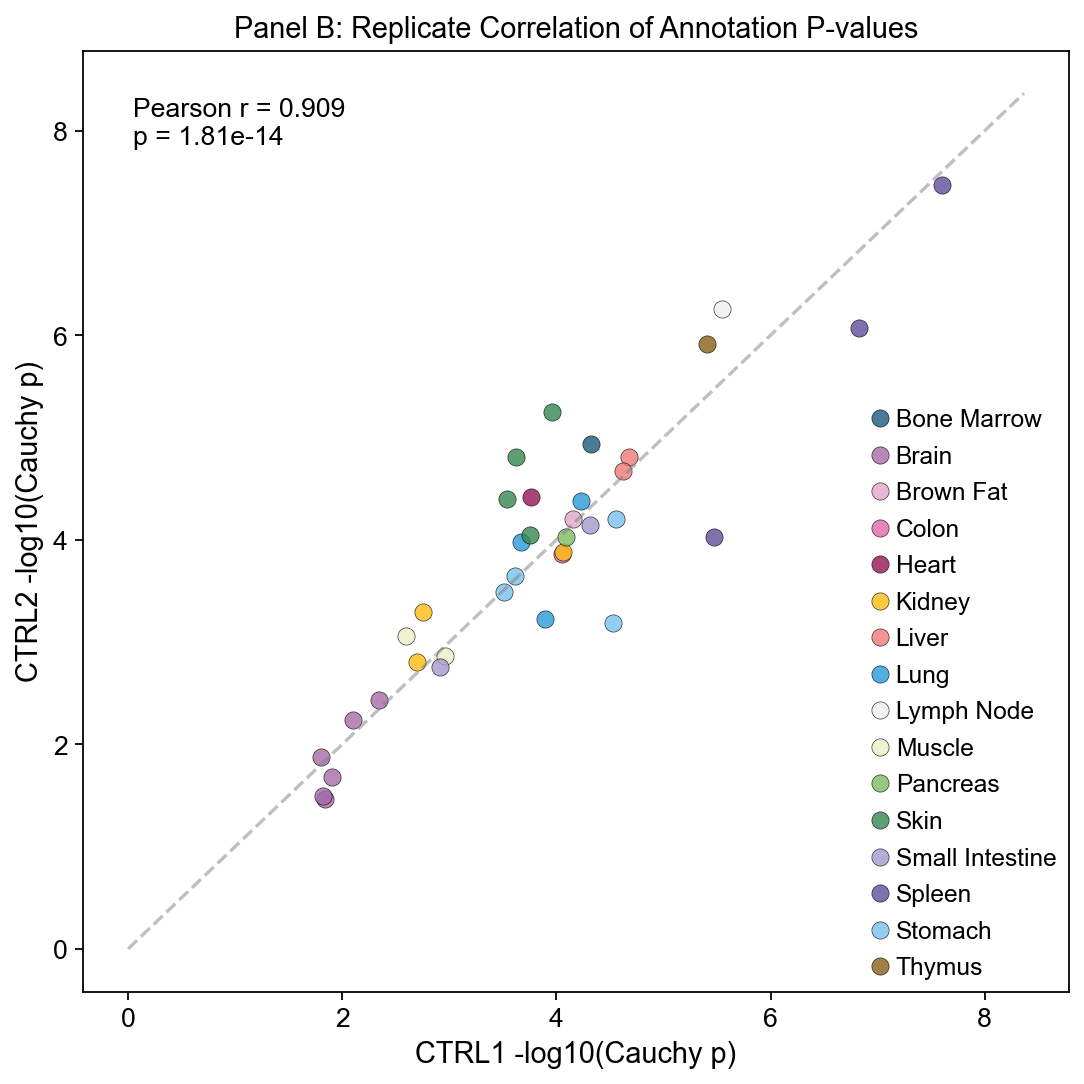

In [5]:
# Find organs with both CTRL1 and CTRL2
organs_both = set(cauchy_all[cauchy_all['replicate'] == 'CTRL1']['organ']) & \
              set(cauchy_all[cauchy_all['replicate'] == 'CTRL2']['organ'])

if len(organs_both) > 0:
    ctrl1_data = cauchy_all[cauchy_all['replicate'] == 'CTRL1'].copy()
    ctrl2_data = cauchy_all[cauchy_all['replicate'] == 'CTRL2'].copy()
    
    # Merge on organ + annotation
    merged = ctrl1_data[['organ', 'annotation', 'logp_cauchy']].merge(
        ctrl2_data[['organ', 'annotation', 'logp_cauchy']],
        on=['organ', 'annotation'], suffixes=('_CTRL1', '_CTRL2')
    )
    
    fig, ax = plt.subplots(figsize=(7, 7))
    colors_map = plt.cm.Set2(np.linspace(0, 1, len(organs_both)))
    for i, organ in enumerate(sorted(organs_both)):
        sub = merged[merged['organ'] == organ]
        ax.scatter(sub['logp_cauchy_CTRL1'], sub['logp_cauchy_CTRL2'],
                   s=60, label=organ, alpha=0.8, edgecolors='k', linewidths=0.3)
    
    if len(merged) >= 3:
        r, pval = pearsonr(merged['logp_cauchy_CTRL1'], merged['logp_cauchy_CTRL2'])
        ax.text(0.05, 0.95, f'Pearson r = {r:.3f}\np = {pval:.2e}',
                transform=ax.transAxes, fontsize=TEXT_FS, va='top')
    
    maxv = max(merged['logp_cauchy_CTRL1'].max(), merged['logp_cauchy_CTRL2'].max()) * 1.1
    ax.plot([0, maxv], [0, maxv], '--', color='grey', alpha=0.5)
    ax.set_xlabel('CTRL1 -log10(Cauchy p)', fontsize=LABEL_FS)
    ax.set_ylabel('CTRL2 -log10(Cauchy p)', fontsize=LABEL_FS)
    ax.set_title('Panel B: Replicate Correlation of Annotation P-values', fontsize=TITLE_FS)
    ax.legend(fontsize=LEGEND_FS)
    ax.tick_params(labelsize=TICK_FS)
    fig.tight_layout()
    save_all_formats(fig, f'{BASE}/figures/S04B_replicate_correlation')
else:
    print('Not enough replicate pairs available yet for correlation analysis.')

## Panel C: Spatial location of top 5 most significant annotations on whole-body map

Top 5 most significant annotations:
           annotation       organ      p_cauchy       sample_name
69      Marginal Zone      Spleen  2.477731e-08      Spleen_CTRL1
70         White Pulp      Spleen  1.481460e-07      Spleen_CTRL1
49  Lymph Node Tissue  Lymph Node  2.831040e-06  Lymph_Node_CTRL1
71           Red Pulp      Spleen  3.396676e-06      Spleen_CTRL1
83      Thymic Cortex      Thymus  3.888362e-06      Thymus_CTRL1


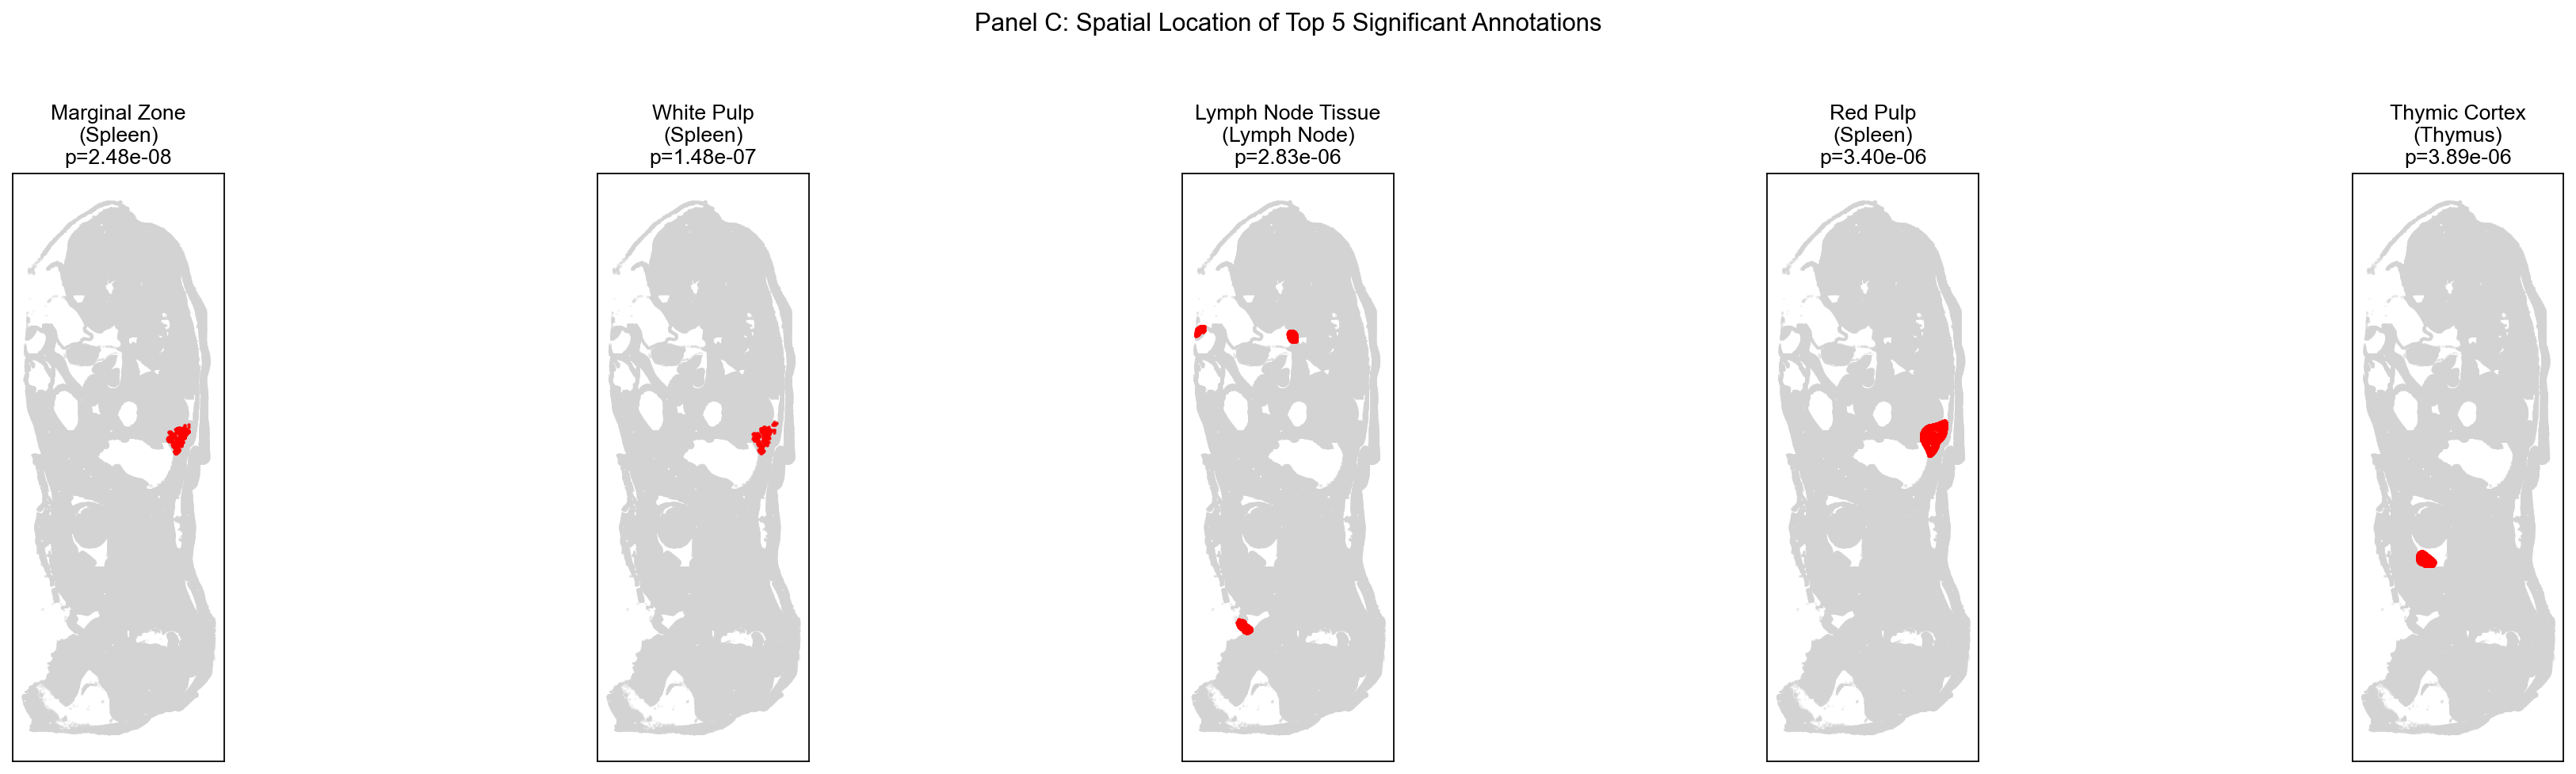

In [6]:
# Get top 5 annotations by Cauchy p-value (using CTRL1 samples)
ctrl1_cauchy = cauchy_all[cauchy_all['replicate'] == 'CTRL1'].copy()
top5 = ctrl1_cauchy.nsmallest(5, 'p_cauchy')[['annotation', 'organ', 'p_cauchy', 'sample_name']]
print('Top 5 most significant annotations:')
print(top5)

# Load whole-body CTRL1 coords
adata_full = ad.read_h5ad(f'{BASE}/data/st/GSE248904_All_Samples.h5ad', backed='r')
obs_ctrl1 = adata_full.obs[adata_full.obs['Sample'] == 'CTRL_1'].copy()
obs_ctrl1 = obs_ctrl1[obs_ctrl1['Organ_Full_Name'] != 'Other'].copy()

# For each top annotation, we need to identify spots in that organ+annotation
# Load per-organ h5ad for annotation info
fig, axes = plt.subplots(1, 5, figsize=(25, 6))

for idx, (_, row) in enumerate(top5.iterrows()):
    ax = axes[idx]
    # Plot all spots in grey
    ax.scatter(obs_ctrl1['x_plotting'], obs_ctrl1['y_plotting'],
              c='lightgrey', s=0.1, alpha=0.3, rasterized=True)
    
    # Load organ h5ad to get annotation
    sname = row['sample_name']
    organ_file = f'{BASE}/data/st/per_organ/{sname}.h5ad'
    adata_org = ad.read_h5ad(organ_file, backed='r')
    org_obs = adata_org.obs.copy()
    highlight = org_obs[org_obs['annotation'] == row['annotation']]
    
    ax.scatter(highlight['x_plotting'], highlight['y_plotting'],
              c='red', s=1, alpha=0.8, rasterized=True)
    ax.set_title(f"{row['annotation']}\n({row['organ']})\np={row['p_cauchy']:.2e}",
                fontsize=TITLE_FS - 1)
    ax.set_aspect('equal')
    ax.invert_yaxis()
    ax.set_xticks([])
    ax.set_yticks([])
    del adata_org

fig.suptitle('Panel C: Spatial Location of Top 5 Significant Annotations', fontsize=TITLE_FS + 1, y=1.02)
fig.tight_layout()
save_all_formats(fig, f'{BASE}/figures/S04C_top5_spatial')